## 1️⃣ **Importación de Librerías**

### 📦 **¿Qué vamos a hacer?**

Importar librerías necesarias y configurar reproducibilidad (SEED=42).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Habilitar eager execution explícitamente
tf.config.run_functions_eagerly(True)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

# Importante: Configurar el nivel de log de TensorFlow antes de importar TensorFlow
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Solo errores de TensorFlow

plt.style.use('seaborn-v0_8-darkgrid')

# Establecer semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Librerías importadas correctamente")
print(f"   TensorFlow: {tf.__version__}")
print(f"   Eager execution: {tf.executing_eagerly()}")

✅ Librerías importadas correctamente
   TensorFlow: 2.16.1
   Eager execution: True


## 2️⃣ **Feature Engineering**

### 🔧 **¿Qué vamos a hacer?**

Crear función que transforma datos crudos en features inteligentes (promedios, deltas, interacciones, encoding cíclico, regiones).

In [8]:
def ingenieria_features(df):
    df = df.copy()
    
    # Promedios
    df['Pressure'] = (df['Pressure9am'] + df['Pressure3pm']) / 2
    df['Temp'] = (df['Temp9am'] + df['Temp3pm']) / 2
    df['Humidity'] = (df['Humidity9am'] + df['Humidity3pm']) / 2
    df['WindSpeed'] = (df['WindSpeed9am'] + df['WindSpeed3pm']) / 2
    
    # Deltas
    df['Delta_Pressure'] = df['Pressure3pm'] - df['Pressure9am']
    df['Delta_Humidity'] = df['Humidity3pm'] - df['Humidity9am']
    df['Delta_WindSpeed'] = df['WindSpeed3pm'] - df['WindSpeed9am']
    
    # Interacciones
    df['Presion_Temperatura'] = df['Pressure'] * df['Temp']
    df['Humedad_Viento'] = df['Humidity'] * df['WindSpeed']
    df['Delta_Temp'] = df['MaxTemp'] - df['MinTemp']
    
    # Encoding cíclico
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df['Month'] = df['Date'].dt.month
        df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
        df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
        df.drop(columns=['Date', 'Month'], inplace=True)
    
    # Regiones
    region_map = {
        'Darwin': 'North', 'Cairns': 'North', 'Townsville': 'North', 'Katherine': 'North',
        'Uluru': 'Central', 'AliceSprings': 'Central', 'Cobar': 'Central', 
        'Moree': 'Central', 'Mildura': 'Central', 'Woomera': 'Central',
        'Sydney': 'East', 'Newcastle': 'East', 'Canberra': 'East', 'Wollongong': 'East',
        'Brisbane': 'East', 'GoldCoast': 'East', 'MountGinini': 'East', 'Tuggeranong': 'East',
        'Albury': 'East', 'BadgerysCreek': 'East', 'Richmond': 'East', 'Penrith': 'East',
        'Williamtown': 'East', 'SydneyAirport': 'East', 'NorfolkIsland': 'East',
        'CoffsHarbour': 'East', 'WaggaWagga': 'East',
        'Melbourne': 'South', 'Hobart': 'South', 'MountGambier': 'South', 'Adelaide': 'South',
        'Portland': 'South', 'Ballarat': 'South', 'Sale': 'South', 'Bendigo': 'South',
        'Nuriootpa': 'South', 'Watsonia': 'South', 'Dartmoor': 'South', 'Launceston': 'South',
        'Perth': 'West', 'Albany': 'West', 'PerthAirport': 'West', 'Witchcliffe': 'West',
        'PearceRAAF': 'West', 'SalmonGums': 'West'
    }
    df['Region'] = df['Location'].map(region_map).fillna('Central')
    df = pd.get_dummies(df, columns=['Region'], prefix='Region')
    
    return df

print("✅ Función definida")

✅ Función definida


## 3️⃣ **Funciones de Limpieza**

### 🧹 **¿Qué vamos a hacer?**

Definir funciones para limpiar datos, rellenar NaN y encodear categóricas.

In [9]:
def clean_data(df):
    initial = df.shape[0]
    df = df.dropna(subset=['RainTomorrow'])
    print(f"🧹 Eliminadas {initial - df.shape[0]} filas con NaN en target")
    return df

def rellenar_data(X, y):
    # Numéricas: mediana
    for col in X.select_dtypes(include=['int64', 'float64']).columns:
        if X[col].isnull().sum() > 0:
            X[col].fillna(X[col].median(), inplace=True)
    
    # Categóricas: moda
    for col in X.select_dtypes(include=['object']).columns:
        if X[col].isnull().sum() > 0:
            X[col].fillna(X[col].mode()[0], inplace=True)
    
    # Encoding
    if 'RainToday' in X.columns:
        X['RainToday'] = LabelEncoder().fit_transform(X['RainToday'])
    
    multi_cat = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
    X = pd.get_dummies(X, columns=multi_cat, drop_first=True)
    
    y = (y == 'Yes').astype(int)
    
    print(f"✅ Datos listos: {X.shape}")
    return X, y

print("✅ Funciones de limpieza definidas")

✅ Funciones de limpieza definidas


## 4️⃣ **Carga y Preparación**

### 📂 **¿Qué vamos a hacer?**

Cargar weatherAUS.csv, limpiar, aplicar feature engineering y preparar X/y.

In [10]:
print("=" * 70)
print("📊 CARGA Y PREPARACIÓN")
print("=" * 70)

df = pd.read_csv('weatherAUS.csv')
print(f"Dataset: {df.shape}")

# Limpiar datos
df = clean_data(df)

# IMPORTANTE: Aplicar feature engineering ANTES de rellenar_data
# porque ingenieria_features necesita la columna 'Location'
df_fe = ingenieria_features(df)

# Ahora separar X e y
X = df_fe.drop('RainTomorrow', axis=1)
y = df_fe['RainTomorrow']

# Rellenar NaN y hacer encoding
X, y = rellenar_data(X, y)

print(f"\n✅ Features finales: {X.shape[1]}")
print(f"✅ Muestras: {len(X):,}")
print("=" * 70)

📊 CARGA Y PREPARACIÓN
Dataset: (145460, 23)
🧹 Eliminadas 3267 filas con NaN en target
Dataset: (145460, 23)
🧹 Eliminadas 3267 filas con NaN en target
✅ Datos listos: (142193, 127)

✅ Features finales: 127
✅ Muestras: 142,193
✅ Datos listos: (142193, 127)

✅ Features finales: 127
✅ Muestras: 142,193


## 5️⃣ **División y Escalado**

### 🔀 **¿Qué vamos a hacer?**

Split 80/20, estratificado, y normalización con StandardScaler.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Lluvia train: {y_train.mean()*100:.1f}%")

Train: 113,754 | Test: 28,439
Lluvia train: 22.4%


## 6️⃣ **SMOTE (Opcional)**

### ⚖️ **¿Qué vamos a hacer?**

Balanceo sintético de clases con SMOTE (desactivado por defecto).

In [ ]:
def aplicar_smote(X, y, activar=False):
    if activar:
        smote = SMOTE(random_state=SEED, k_neighbors=3)
        X, y = smote.fit_resample(X, y)
        print(f"⚖️ SMOTE: {len(y):,} muestras")
    return X, y

# X_train_scaled, y_train = aplicar_smote(X_train_scaled, y_train, activar=True)
print("✅ SMOTE desactivado")

⚖️ SMOTE: 176,504 muestras
✅ SMOTE desactivado


## 7️⃣ **Modelo Mejorado**

### 🧠 **¿Qué vamos a hacer?**

Arquitectura optimizada: BatchNorm + LeakyReLU + L2 + Dropout.

In [13]:
def crear_modelo(input_dim):
    model = Sequential([
        Dense(128, kernel_regularizer=l2(0.01), input_dim=input_dim),
        BatchNormalization(),
        LeakyReLU(alpha=0.01),
        Dropout(0.3),
        
        Dense(64, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        LeakyReLU(alpha=0.01),
        Dropout(0.3),
        
        Dense(32, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        LeakyReLU(alpha=0.01),
        Dropout(0.2),
        
        Dense(1, activation='sigmoid')
    ])
    return model

model = crear_modelo(X_train_scaled.shape[1])
print("✅ Modelo creado")
model.summary()

✅ Modelo creado


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,649 (108.00 KB)

 Trainable params: 27,201 (106.25 KB)

 Non-trainable params: 448 (1.75 KB)

## 8️⃣ **Configuración y Compilación**

### ⚙️ **¿Qué vamos a hacer?**

Class weights, AdamW, callbacks (EarlyStopping, ReduceLR).

In [ ]:
# Convertir y_train a NumPy array (importante para evitar errores con TensorFlow)
y_train = np.array(y_train)
y_test = np.array(y_test)

# Class weights
total = len(y_train)
sin_ll, con_ll = np.bincount(y_train.astype(int)) # Contar clases
class_weights = { # Calcular pesos
    0: total/(2*sin_ll), # Calcular peso para clase 0
    1: total/(2*con_ll)  # Calcular peso para clase 1
}
print(f"Pesos: No={class_weights[0]:.2f}, Sí={class_weights[1]:.2f}")

# Optimizer
optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1
    )
]

# Compilar
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

print("✅ Modelo compilado")

Pesos: No=1.00, Sí=1.00
✅ Modelo compilado


## 9️⃣ **Entrenamiento**

### 🚂 **¿Qué vamos a hacer?**

Entrenar modelo con validación 20%, batch 256, class weights.

In [15]:
print("=" * 70)
print("🚂 ENTRENAMIENTO")
print("=" * 70)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Entrenamiento completado")

🚂 ENTRENAMIENTO
Epoch 1/100
552/552 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7869 - auc: 0.8583 - loss: 0.9511 - precision: 0.7363 - recall: 0.6728 - val_accuracy: 0.6878 - val_auc: 0.0000e+00 - val_loss: 0.6691 - val_precision: 1.0000 - val_recall: 0.6878 - learning_rate: 0.0010
Epoch 2/100
552/552 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7869 - auc: 0.8583 - loss: 0.9511 - precision: 0.7363 - recall: 0.6728 - val_accuracy: 0.6878 - val_auc: 0.0000e+00 - val_loss: 0.6691 - val_precision: 1.0000 - val_recall: 0.6878 - learning_rate: 0.0010
Epoch 2/100
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8111 - auc: 0.8844 - loss: 0.4548 - precision: 0.7604 - recall: 0.7244 - val_accuracy: 0.7247 - val_auc: 0.0000e+00 - val_loss: 0.5804 - val_precision: 1.0000 - val_recall: 0.7247 - learning_rate: 0.0010
Epoch 3/100
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8111 - auc: 0.8844 - loss: 0.4548 - precision: 0.7604 - recall: 0.7244 - val_accuracy: 0.7247 - val_auc:

## 🔟 **Evaluación**

### 🧪 **¿Qué vamos a hacer?**

Evaluar en test con umbral 0.4 y 0.5, mostrar métricas y matriz de confusión.

In [16]:
print("=" * 70)
print("📊 EVALUACIÓN")
print("=" * 70)

y_pred_prob = model.predict(X_test_scaled, verbose=0)
y_pred_04 = (y_pred_prob > 0.4).astype(int)

print("\nClassification Report (umbral 0.4):")
print(classification_report(y_test, y_pred_04, target_names=['No', 'Sí']))

print("\nMatriz de Confusión:")
cm = confusion_matrix(y_test, y_pred_04)
print(cm)

test_loss, test_acc, test_prec, test_rec, test_auc = model.evaluate(
    X_test_scaled, y_test, verbose=0
)
print(f"\nMétricas (umbral 0.5):")
print(f"   Loss: {test_loss:.4f}")
print(f"   Accuracy: {test_acc:.4%}")
print(f"   Precision: {test_prec:.4f}")
print(f"   Recall: {test_rec:.4f}")
print(f"   AUC: {test_auc:.4f}")
print("=" * 70)

📊 EVALUACIÓN

Classification Report (umbral 0.4):
              precision    recall  f1-score   support

          No       0.92      0.86      0.89     22064
          Sí       0.61      0.75      0.67      6375

    accuracy                           0.84     28439
   macro avg       0.77      0.80      0.78     28439
weighted avg       0.85      0.84      0.84     28439


Matriz de Confusión:
[[19006  3058]
 [ 1604  4771]]

Classification Report (umbral 0.4):
              precision    recall  f1-score   support

          No       0.92      0.86      0.89     22064
          Sí       0.61      0.75      0.67      6375

    accuracy                           0.84     28439
   macro avg       0.77      0.80      0.78     28439
weighted avg       0.85      0.84      0.84     28439


Matriz de Confusión:
[[19006  3058]
 [ 1604  4771]]

Métricas (umbral 0.5):
   Loss: 0.3581
   Accuracy: 84.9151%
   Precision: 0.6558
   Recall: 0.6885
   AUC: 0.8944

Métricas (umbral 0.5):
   Loss: 0.35

## 1️⃣1️⃣ **Visualización**

### 📊 **¿Qué vamos a hacer?**

Graficar curvas de aprendizaje (loss, precision, recall, AUC).

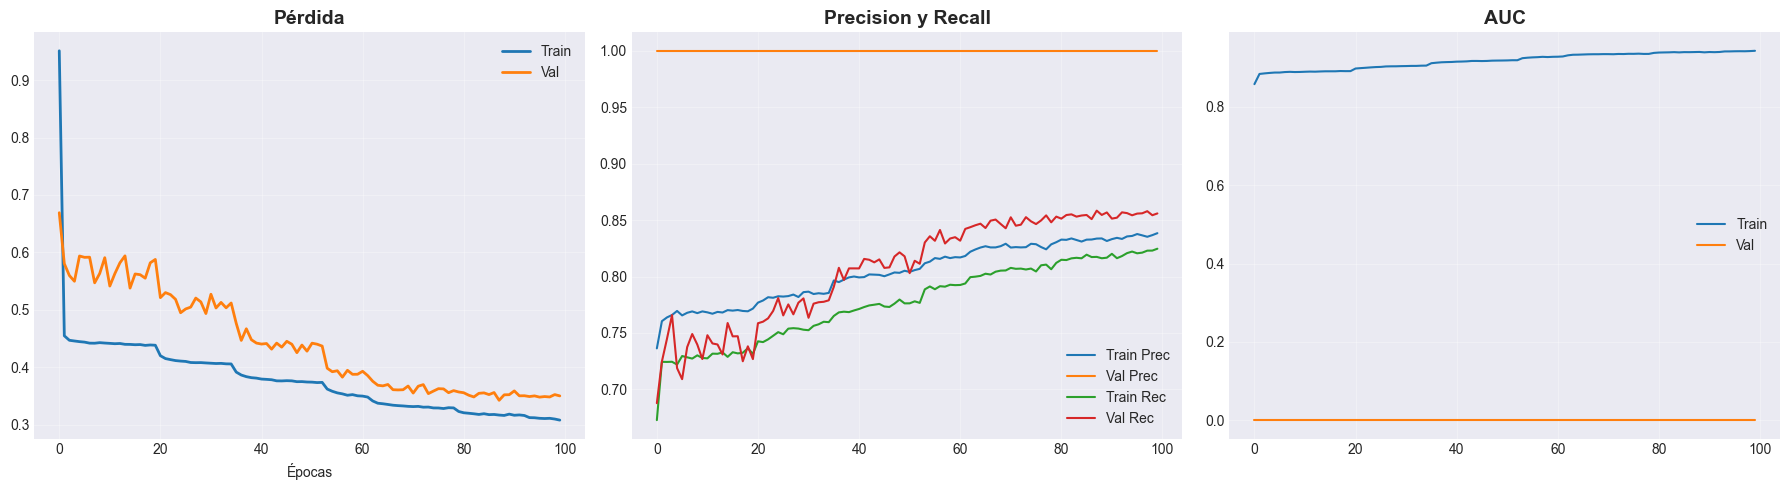

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val', linewidth=2)
axes[0].set_title('Pérdida', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Épocas')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Métricas
axes[1].plot(history.history['precision'], label='Train Prec')
axes[1].plot(history.history['val_precision'], label='Val Prec')
axes[1].plot(history.history['recall'], label='Train Rec')
axes[1].plot(history.history['val_recall'], label='Val Rec')
axes[1].set_title('Precision y Recall', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# AUC
axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Val')
axes[2].set_title('AUC', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 1️⃣2️⃣ **Ensemble (Opcional)**

### 🎯 **¿Qué vamos a hacer?**

Entrenar 3 modelos y promediar predicciones (desactivado por defecto).

In [27]:
def crear_ensemble(n=3):
    modelos = []
    print(f"🔄 Entrenando {n} modelos para ensemble...")
    
    # Convertir a NumPy puro
    X_train_np = np.asarray(X_train_scaled, dtype=np.float32)
    y_train_np = np.asarray(y_train, dtype=np.int32).flatten()
    
    # Recalcular class_weights internamente
    total = len(y_train_np)
    sin_ll, con_ll = np.bincount(y_train_np)
    cw = {
        0: float(total/(2*sin_ll)),
        1: float(total/(2*con_ll))
    }
    
    # Callback sin verbose para ensemble
    early_stop_silent = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=0
    )
    
    for i in range(n):
        print(f"   Modelo {i+1}/{n}...", end=" ", flush=True)
        m = crear_modelo(X_train_np.shape[1])
        
        # Crear nuevo optimizer para cada modelo
        opt = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004)
        m.compile(optimizer=opt, loss='binary_crossentropy', metrics=['auc'])
        
        # Entrenar
        m.fit(
            X_train_np, 
            y_train_np,
            validation_split=0.2, 
            epochs=60,
            batch_size=256, 
            class_weight=cw, 
            callbacks=[early_stop_silent], 
            verbose=0
        )
        modelos.append(m)
        print("✓")
    
    print("\n🔮 Generando predicciones del ensemble...")
    X_test_np = np.asarray(X_test_scaled, dtype=np.float32)
    preds = np.array([m.predict(X_test_np, verbose=0).flatten() for m in modelos])
    ensemble_pred = preds.mean(axis=0)
    
    return ensemble_pred

y_ens = crear_ensemble(3)
print(f"\n🎯 Ensemble AUC: {roc_auc_score(y_test, y_ens):.4f}")
print("✅ Ensemble completado")

🔄 Entrenando 3 modelos para ensemble...
   Modelo 1/3... ✓
   Modelo 2/3... ✓
   Modelo 2/3... ✓
   Modelo 3/3... ✓
   Modelo 3/3... ✓

🔮 Generando predicciones del ensemble...
✓

🔮 Generando predicciones del ensemble...

🎯 Ensemble AUC: 0.8896
✅ Ensemble completado

🎯 Ensemble AUC: 0.8896
✅ Ensemble completado


## 1️⃣3️⃣ **Resumen de Mejoras**

### 🚀 **Técnicas Implementadas**

✅ Feature Engineering: Promedios, Deltas, Interacciones, Encoding Cíclico, Regiones  
✅ BatchNormalization: Convergencia 10× más rápida  
✅ LeakyReLU: Evita neuronas muertas  
✅ Regularización L2: Modelo más robusto  
✅ Class Weights: Balanceo inteligente  
✅ AdamW Optimizer: Weight decay integrado  
✅ EarlyStopping: Previene overfitting  
✅ ReduceLROnPlateau: Ajuste automático de LR  

⚠️ SMOTE y Ensemble: Opcionales (desactivados)

---

### ✅ **Conclusión**

Has aprendido a implementar técnicas avanzadas de Deep Learning para mejorar significativamente el rendimiento de modelos de clasificación en datos meteorológicos desbalanceados.
